In [5]:
import time

#from visualization.point_clouds import vis_2pcs_aligned_vs_misaligned, vis_pc
from utils.optimize_parameters import optimize_with_ax

In [ ]:

t1 = time.perf_counter()
# optimize_with_ax(samples_training=25, samples_test=25)
optimize_with_ax(samples_training=5, samples_test=5)

print(f"It took {round(time.perf_counter()-t1)} seconds to run basic run")
#model, X_train, X_test, y_train, y_test = main.differential_entropy_classification()

In [1]:
from utils.data_handling import read_nuscenes_data, split_data
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression

PC_scenes = read_nuscenes_data(data_folder = 'data/nuscenes/', version="v1.0-trainval",
                               n_scenes=200, n_samples=200, downsample_factor=2)

PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=130)
del PC_scenes
scale_factor = 5
params = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}
X_train, y_train = differential_entropy_dataset(PC_scenes_training, params)
del PC_scenes_training
X_test, y_test = differential_entropy_dataset(PC_scenes_test, params)
del PC_scenes_test
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params}")
print("Finito!")


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 28.541 seconds.
Reverse indexing ...
Done reverse indexing in 7.3 seconds.
We have collected 1 scenes
We have collected 2 scenes
We have collected 3 scenes
We have collected 4 scenes
We have collected 5 scenes
We have collected 6 scenes
We have collected 7 scenes
We have collected 8 scenes
We have collected 9 scenes
We have collected 10 scenes
We have collected 11 scenes
We have collected 12 scenes
We have collected 13 scenes
We have collected 14 scenes
We have collected 15 scenes
We have collected 16 scenes
We have collected 17 scenes
We have collected 18 scenes
We have collected 19 scenes
We have collected 20 scenes
We have collected 21 scenes
We have collected 22 scenes
We have collected 23 scenes
We have collected 24 sc

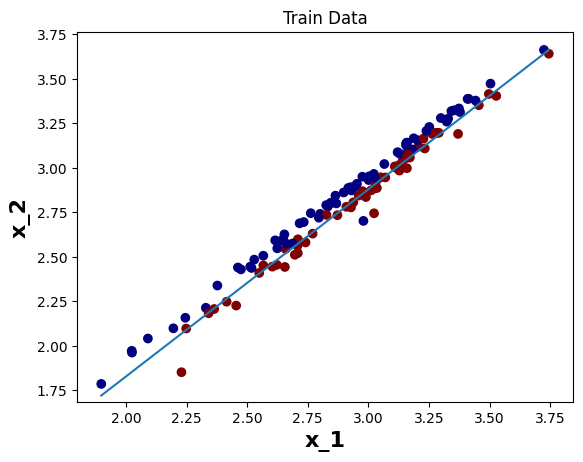

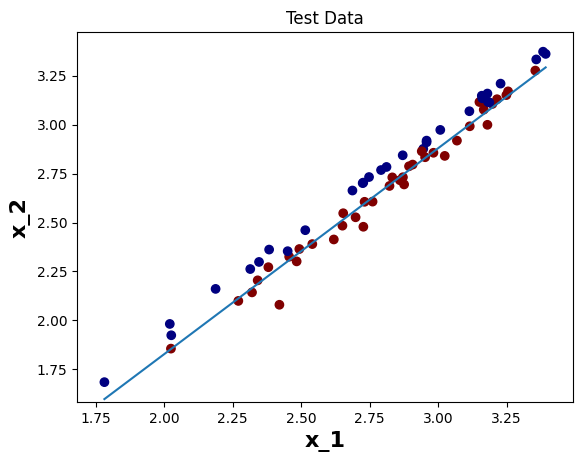

In [8]:
from visualization.classifications import model_plot

# Train Data
model_plot(model,X_train,y_train,'Train Data')
# Test Dataset Results
model_plot(model,X_test,y_test,'Test Data')

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

def plot_point_cloud_interactive(pc):
    def plot(elev=30, azim=30):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        xs = pc[:, 0]
        ys = pc[:, 1]
        zs = pc[:, 2]

        ax.scatter(xs, ys, zs, marker='o')

        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

        ax.view_init(elev, azim)
        plt.show()

    widgets.interact(plot, elev=(-90, 90, 5), azim=(-180, 180, 5))

PC_scenes = read_nuscenes_data()
PC_scene = PC_scenes[0]
PC_pair = PC_scene[0]

#plot_point_cloud_interactive(PC_pair.PC0.pc.cpu().numpy())


import plotly.graph_objs as go

def plot_point_cloud_plotly(pc):
    x, y, z = pc[:, 0], pc[:, 1], pc[:, 2]

    trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            opacity=0.8
        )
    )

    layout = go.Layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

plot_point_cloud_plotly(PC_pair.PC0.pc.cpu().numpy())
